In [1]:
data_path = "/home/husted42/Downloads/European_data_2000.csv"

# load the data
import pandas as pd
df = pd.read_csv(
    data_path,
    sep=",",
    engine="python",
    quotechar='"',
    on_bad_lines="skip"   
)

print("Columns in the dataset: ")
print(df.columns)
print("\nShape of the dataset: ", df.shape)
print("Unique titles ", df['titleId'].nunique())
print("Duplicate titles ", df['titleId'].duplicated().sum())
print("Missing values: ", df.isnull().sum().sum())


Columns in the dataset: 
Index(['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear',
       'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes',
       'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage',
       'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort',
       'plotMedium', 'plotLong', 'genres', 'keywords', 'production'],
      dtype='object')

Shape of the dataset:  (2000, 23)
Unique titles  2000
Duplicate titles  0
Missing values:  0


In [2]:
'''
Columns in the dataset: 
Index(['titleId', 'imdbUrl', 'originalTitle', 'titleType', 'releaseYear',
       'runtimeMinutes', 'isAdult', 'imdbRating', 'numberOfVotes',
       'allCountries', 'mainCountry', 'allLanguages', 'firstLanguage',
       'englishTitle', 'topFiveActors', 'directors', 'writers', 'plotShort',
       'plotMedium', 'plotLong', 'genres', 'keywords', 'production'],
      dtype='object')
'''
# Print all harry potter movies
harry_potter_movies = df[df["originalTitle"].str.contains("Harry Potter", case=False, na=False)]
print(harry_potter_movies)

        titleId                                imdbUrl  \
140   tt0304141  https://www.imdb.com/title/tt0304141/   
392   tt0241527  https://www.imdb.com/title/tt0241527/   
792   tt0330373  https://www.imdb.com/title/tt0330373/   
960   tt0417741  https://www.imdb.com/title/tt0417741/   
1383  tt1201607  https://www.imdb.com/title/tt1201607/   
1654  tt0926084  https://www.imdb.com/title/tt0926084/   
1823  tt0295297  https://www.imdb.com/title/tt0295297/   

                                      originalTitle titleType  releaseYear  \
140        Harry Potter and the Prisoner of Azkaban     movie       2004.0   
392           Harry Potter and the Sorcerer's Stone     movie       2001.0   
792             Harry Potter and the Goblet of Fire     movie       2005.0   
960          Harry Potter and the Half-Blood Prince     movie       2009.0   
1383  Harry Potter and the Deathly Hallows - Part 2     movie       2011.0   
1654  Harry Potter and the Deathly Hallows - Part 1     movie      

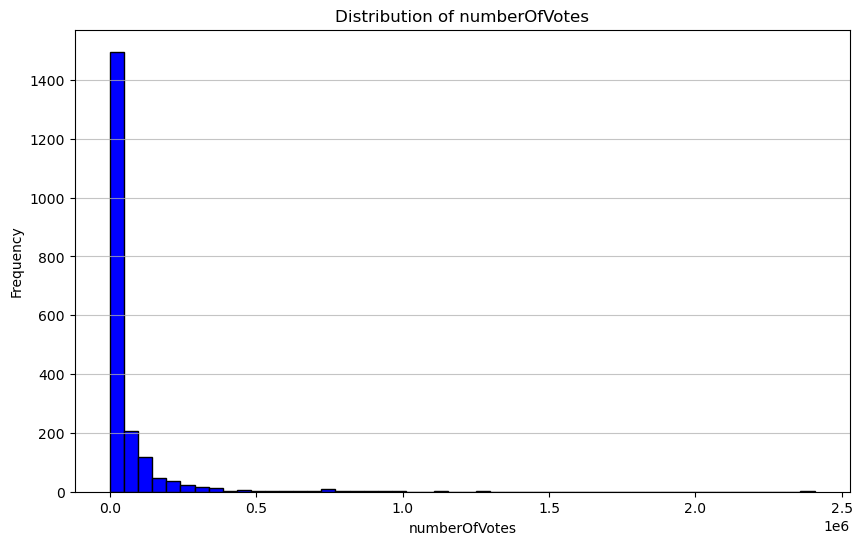

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['numberOfVotes'], bins=50, color='blue', edgecolor='black')
plt.title('Distribution of numberOfVotes')
plt.xlabel('numberOfVotes')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


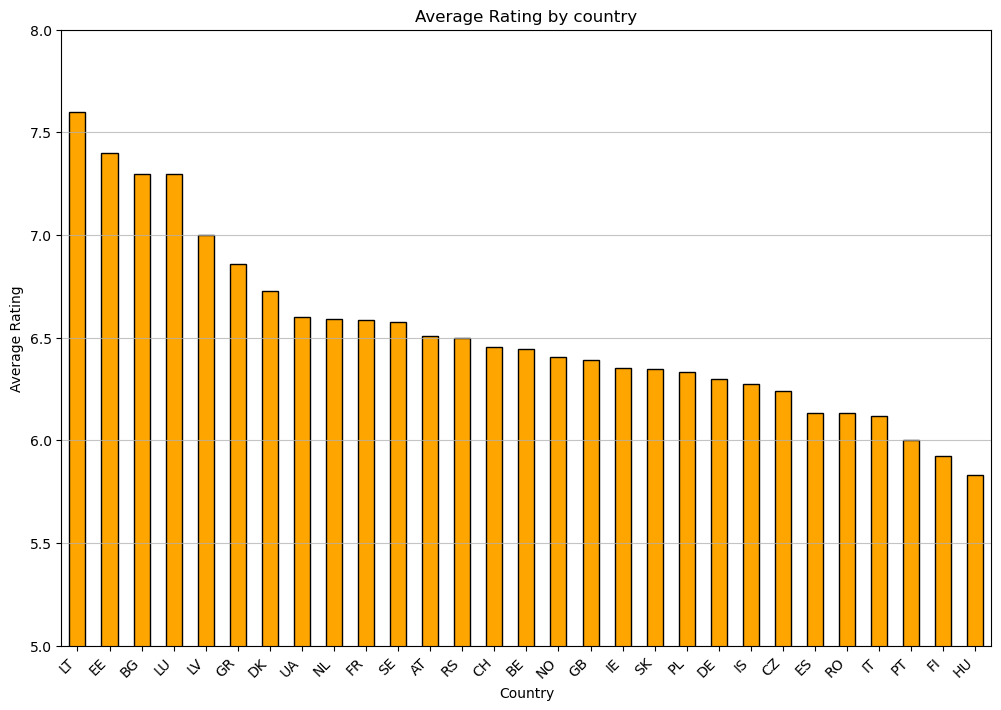

In [4]:
# Plot the average rating by genre
plt.figure(figsize=(12, 8))
df_genre = df.groupby('mainCountry')['imdbRating'].mean().sort_values(ascending=False)
df_genre.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Rating by country')
plt.xlabel('Country')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(5, 8)
plt.grid(axis='y', alpha=0.75)
plt.show()

T-statistic:  6.4266598906101455
P-value:  1.6892944891254477e-10


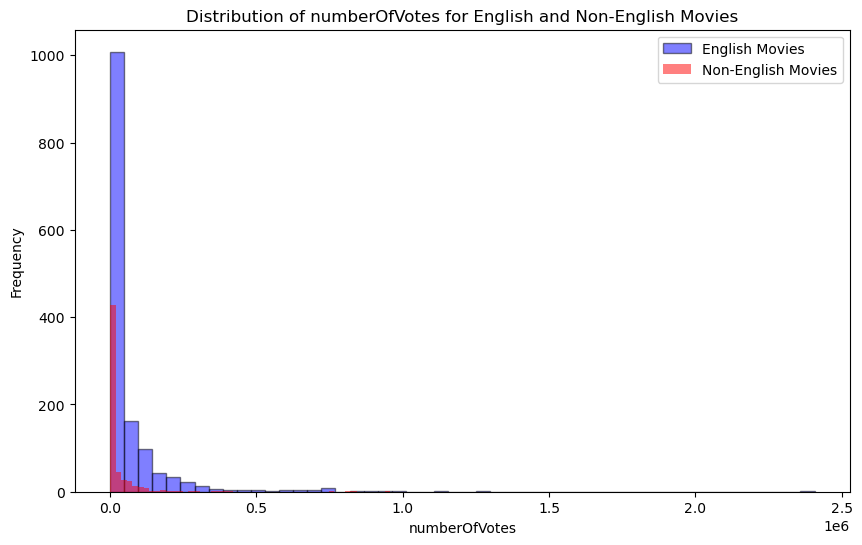

In [5]:
# P-value test for checking english speaking movies have more number of votes than non-english speaking movies
from scipy import stats
english_movies = df[df['firstLanguage'] == 'en']['numberOfVotes']
non_english_movies = df[df['firstLanguage'] != 'en']['numberOfVotes']
t_stat, p_value = stats.ttest_ind(english_movies, non_english_movies, equal_var=False)
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

# plot the number og votes for english and non-english movies
plt.figure(figsize=(10, 6))
plt.hist(english_movies, bins=50, alpha=0.5, label='English Movies', color='blue', edgecolor='black')
plt.hist(non_english_movies, bins=50, alpha=0.5, label='Non-English Movies', color='red')
plt.title('Distribution of numberOfVotes for English and Non-English Movies')
plt.xlabel('numberOfVotes')
plt.ylabel('Frequency')
plt.legend()

# Most defining words

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

df_word = df[['genres', 'keywords']]

genres_list = df_word["genres"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)
mlb = MultiLabelBinarizer()
genre_dummies = mlb.fit_transform(genres_list)

# Turn encoding into a DataFrame and concatenate with original DataFrame
genre_cols = [f"genre_{g}" for g in mlb.classes_]
genre_df = pd.DataFrame(genre_dummies, columns=genre_cols, index=df_word.index)
df_genre = pd.concat([df_word, genre_df], axis=1)
df_genre.head()

,genres,keywords,genre_Action,genre_Adult,genre_Adventure,genre_Animation,genre_Biography,genre_Comedy,genre_Crime,genre_Documentary,...,genre_Music,genre_Musical,genre_Mystery,genre_News,genre_Romance,genre_Sci-Fi,genre_Sport,genre_Thriller,genre_War,genre_Western
0,Drama,"poland, 1960s, jew, novitiate, family secret, ...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"Horror, Thriller","stalker, female nudity, female topless nudity,...",0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,Comedy,"new york city, brassiere, painting oneself, ca...",0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,"Action, Comedy","espionage, american agent, female british spy,...",1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,"Comedy, Drama","hotel, writer, grandson, friendship, impersona...",0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2

# Keep only relevant columns
df_word = df[['genres', 'keywords']].copy()

# ---------- 1. Process genres ----------
genres_list = df_word["genres"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)

mlb = MultiLabelBinarizer()
genre_dummies = mlb.fit_transform(genres_list)

genre_cols = [f"genre_{g}" for g in mlb.classes_]
genre_df = pd.DataFrame(genre_dummies, columns=genre_cols, index=df_word.index)

df_genre = pd.concat([df_word, genre_df], axis=1)

# ---------- 2. Process keywords ----------
# Assumes keywords are comma-separated, like: "space, future, robot"
df_genre["keywords_clean"] = df_genre["keywords"].fillna("").apply(
    lambda s: ",".join([k.strip().lower() for k in s.split(",") if k.strip()])
)

# CountVectorizer using comma as separator
vectorizer = CountVectorizer(
    tokenizer=lambda x: x.split(","),
    preprocessor=lambda x: x,
    token_pattern=None,
    binary=True,        # presence/absence of keyword
    min_df=5            # ignore very rare keywords
)

X_keywords = vectorizer.fit_transform(df_genre["keywords_clean"])
keyword_names = vectorizer.get_feature_names_out()
print(f"Number of unique keywords: {len(keyword_names)}")

# ---------- 3. Find most defining keywords per genre ----------
top_n = 15
genre_keyword_results = {}

for genre_col in genre_cols:
    y = df_genre[genre_col]

    # Skip genres with too few positive examples
    if y.sum() < 5:
        continue

    chi_scores, p_values = chi2(X_keywords, y)

    result_df = pd.DataFrame({
        "keyword": keyword_names,
        "chi2_score": chi_scores,
        "p_value": p_values
    }).sort_values("chi2_score", ascending=False)

    genre_keyword_results[genre_col] = result_df.head(top_n)

# ---------- 4. Print results ----------
for genre, result in genre_keyword_results.items():
    print(f"\nTop keywords for {genre}:")
    print(result.to_string(index=False))

Number of unique keywords: 9327

Top keywords for genre_Action:
            keyword  chi2_score      p_value
hand to hand combat  365.269780 2.005059e-81
       martial arts  354.533813 4.363705e-79
        machine gun  296.535990 1.872737e-66
           shootout  294.812259 4.446700e-66
           gunfight  291.758441 2.057842e-65
   held at gunpoint  277.232607 3.010714e-62
  shot in the chest  268.551029 2.348060e-60
        action hero  258.194315 4.247346e-58
              brawl  256.711954 8.938177e-58
          explosion  251.604980 1.160230e-56
          fistfight  248.825396 4.682914e-56
             pistol  245.464713 2.530514e-55
 mixed martial arts  243.485028 6.836536e-55
          tough guy  234.159788 7.382386e-53
       one man army  214.758611 1.258130e-48

Top keywords for genre_Adventure:
         keyword  chi2_score      p_value
  snow adventure  171.949263 2.776143e-39
      slimehouse  160.933077 7.075968e-37
          rescue  147.066717 7.588336e-34
  talking ani

In [8]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# -----------------------------------
# 1. Keep relevant columns
# -----------------------------------
df_text = df[['plotMedium', 'imdbRating']].copy()
df_text = df_text.dropna(subset=['plotMedium', 'imdbRating']).copy()
df_text["plot_clean"] = df_text["plotMedium"].astype(str)

# -----------------------------------
# 2. Vectorize text as binary presence
# -----------------------------------
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2),
    binary=True
)

X = vectorizer.fit_transform(df_text["plot_clean"])
terms = vectorizer.get_feature_names_out()

term_df = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_text.index,
    columns=terms
)

# -----------------------------------
# 3. Compute average IMDb rating per term
# -----------------------------------
results = []

for term in terms:
    mask = term_df[term] > 0
    n_movies = mask.sum()

    if n_movies < 10:
        continue

    avg_rating_with_term = df_text.loc[mask, "imdbRating"].mean()
    avg_rating_without_term = df_text.loc[~mask, "imdbRating"].mean()
    diff = avg_rating_with_term - avg_rating_without_term

    results.append({
        "term": term,
        "n_movies": int(n_movies),
        "avg_rating_with_term": avg_rating_with_term,
        "avg_rating_without_term": avg_rating_without_term,
        "rating_difference": diff
    })

result_df = pd.DataFrame(results).sort_values(
    "rating_difference", ascending=False
)

print(result_df.head(30).to_string(index=False))

      term  n_movies  avg_rating_with_term  avg_rating_without_term  rating_difference
      1945        11              7.454545                 6.380493           1.074053
   details        12              7.408333                 6.380231           1.028102
    actors        10              7.380000                 6.381407           0.998593
 interview        12              7.316667                 6.380785           0.935882
    jewish        23              7.308696                 6.375670           0.933025
interviews        11              7.309091                 6.381297           0.927794
companions        10              7.290000                 6.381859           0.908141
     honor        13              7.284615                 6.380523           0.904092
    daniel        13              7.253846                 6.380725           0.873121
      wwii        12              7.250000                 6.381187           0.868813
   foreign        13              7.230769 

In [9]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer

# -----------------------------------
# 1. Keep relevant columns
# -----------------------------------
df_text = df[['genres', 'plotMedium', 'imdbRating']].copy()
df_text = df_text.dropna(subset=['genres', 'plotMedium', 'imdbRating']).copy()
df_text["plot_clean"] = df_text["plotMedium"].astype(str)

# -----------------------------------
# 2. Process genres
# -----------------------------------
genres_list = df_text["genres"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)

mlb = MultiLabelBinarizer()
genre_dummies = mlb.fit_transform(genres_list)

genre_names = list(mlb.classes_)
genre_df = pd.DataFrame(
    genre_dummies,
    columns=genre_names,
    index=df_text.index
)

df_genre = pd.concat([df_text, genre_df], axis=1)

# -----------------------------------
# 3. Vectorize text as binary presence
# -----------------------------------
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2),
    binary=True
)

X = vectorizer.fit_transform(df_genre["plot_clean"])
terms = vectorizer.get_feature_names_out()

term_df = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_genre.index,
    columns=terms
)

# -----------------------------------
# 4. Compute rating difference per term within each genre
# -----------------------------------
top_n = 20
min_movies_genre = 30
min_term_count_in_genre = 5

genre_term_results = {}

for genre in genre_names:
    genre_mask = df_genre[genre] == 1
    n_genre_movies = int(genre_mask.sum())

    if n_genre_movies < min_movies_genre:
        continue

    genre_subset = df_genre.loc[genre_mask]
    genre_term_subset = term_df.loc[genre_mask]

    results = []

    for term in terms:
        mask = genre_term_subset[term] > 0
        n_with_term = int(mask.sum())
        n_without_term = int((~mask).sum())

        # skip rare terms inside this genre
        if n_with_term < min_term_count_in_genre or n_without_term < min_term_count_in_genre:
            continue

        avg_rating_with_term = genre_subset.loc[mask, "imdbRating"].mean()
        avg_rating_without_term = genre_subset.loc[~mask, "imdbRating"].mean()
        diff = avg_rating_with_term - avg_rating_without_term

        results.append({
            "genre": genre,
            "term": term,
            "n_genre_movies": n_genre_movies,
            "n_with_term": n_with_term,
            "n_without_term": n_without_term,
            "avg_rating_with_term": avg_rating_with_term,
            "avg_rating_without_term": avg_rating_without_term,
            "rating_difference": diff
        })

    if results:
        result_df = pd.DataFrame(results).sort_values(
            "rating_difference", ascending=False
        )
        genre_term_results[genre] = result_df.head(top_n)

# -----------------------------------
# 5. Print results
# -----------------------------------
for genre, result in genre_term_results.items():import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import CountVectorizer

# -----------------------------------
# 1. Keep relevant columns
# -----------------------------------
df_text = df[['genres', 'plotMedium', 'imdbRating']].copy()
df_text = df_text.dropna(subset=['genres', 'plotMedium', 'imdbRating']).copy()
df_text["plot_clean"] = df_text["plotMedium"].astype(str)

# -----------------------------------
# 2. Process genres
# -----------------------------------
genres_list = df_text["genres"].fillna("").apply(
    lambda s: [g.strip() for g in s.split(",") if g.strip()]
)

mlb = MultiLabelBinarizer()
genre_dummies = mlb.fit_transform(genres_list)

genre_names = list(mlb.classes_)
genre_df = pd.DataFrame(
    genre_dummies,
    columns=genre_names,
    index=df_text.index
)

df_genre = pd.concat([df_text, genre_df], axis=1)

# -----------------------------------
# 3. Vectorize text as binary presence
# -----------------------------------
vectorizer = CountVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=10,
    max_df=0.8,
    ngram_range=(1, 2),
    binary=True
)

X = vectorizer.fit_transform(df_genre["plot_clean"])
terms = vectorizer.get_feature_names_out()

term_df = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_genre.index,
    columns=terms
)

# -----------------------------------
# 4. Compute rating difference per term within each genre
# -----------------------------------
top_n = 20
min_movies_genre = 30
min_term_count_in_genre = 5

genre_term_results = {}

for genre in genre_names:
    genre_mask = df_genre[genre] == 1
    n_genre_movies = int(genre_mask.sum())

    if n_genre_movies < min_movies_genre:
        continue

    genre_subset = df_genre.loc[genre_mask]
    genre_term_subset = term_df.loc[genre_mask]

    results = []

    for term in terms:
        mask = genre_term_subset[term] > 0
        n_with_term = int(mask.sum())
        n_without_term = int((~mask).sum())

        # skip rare terms inside this genre
        if n_with_term < min_term_count_in_genre or n_without_term < min_term_count_in_genre:
            continue

        avg_rating_with_term = genre_subset.loc[mask, "imdbRating"].mean()
        avg_rating_without_term = genre_subset.loc[~mask, "imdbRating"].mean()
        diff = avg_rating_with_term - avg_rating_without_term

        results.append({
            "genre": genre,
            "term": term,
            "n_genre_movies": n_genre_movies,
            "n_with_term": n_with_term,
            "n_without_term": n_without_term,
            "avg_rating_with_term": avg_rating_with_term,
            "avg_rating_without_term": avg_rating_without_term,
            "rating_difference": diff
        })

    if results:
        result_df = pd.DataFrame(results).sort_values(
            "rating_difference", ascending=False
        )
        genre_term_results[genre] = result_df.head(top_n)

# -----------------------------------
# 5. Print results
# -----------------------------------
for genre, result in genre_term_results.items():
    print(f"\nTop terms linked to higher IMDb rating within genre: {genre}")
    print(result.to_string(index=False))
    print(f"\nTop terms linked to higher IMDb rating within genre: {genre}")
    print(result.to_string(index=False))

    


Top terms linked to higher IMDb rating within genre: Action
 genre         term  n_genre_movies  n_with_term  n_without_term  avg_rating_with_term  avg_rating_without_term  rating_difference
Action         seen             310            5             305              7.460000                 6.043607           1.416393
Action    situation             310            5             305              7.220000                 6.047541           1.172459
Action      germans             310            6             304              7.166667                 6.044737           1.121930
Action         boat             310            7             303              7.157143                 6.041254           1.115889
Action          mob             310            5             305              7.140000                 6.048852           1.091148
Action organization             310            7             303              7.000000                 6.044884           0.955116
Action  immediately   

In [10]:
all_results = pd.concat(genre_term_results.values(), ignore_index=True)
all_results = all_results.sort_values(
    ["genre", "rating_difference"], ascending=[True, False]
)
print(all_results.to_string(index=False))

      genre         term  n_genre_movies  n_with_term  n_without_term  avg_rating_with_term  avg_rating_without_term  rating_difference
     Action         seen             310            5             305              7.460000                 6.043607           1.416393
     Action    situation             310            5             305              7.220000                 6.047541           1.172459
     Action      germans             310            6             304              7.166667                 6.044737           1.121930
     Action         boat             310            7             303              7.157143                 6.041254           1.115889
     Action          mob             310            5             305              7.140000                 6.048852           1.091148
     Action organization             310            7             303              7.000000                 6.044884           0.955116
     Action  immediately             310        

In [11]:
!pip install adjustText

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


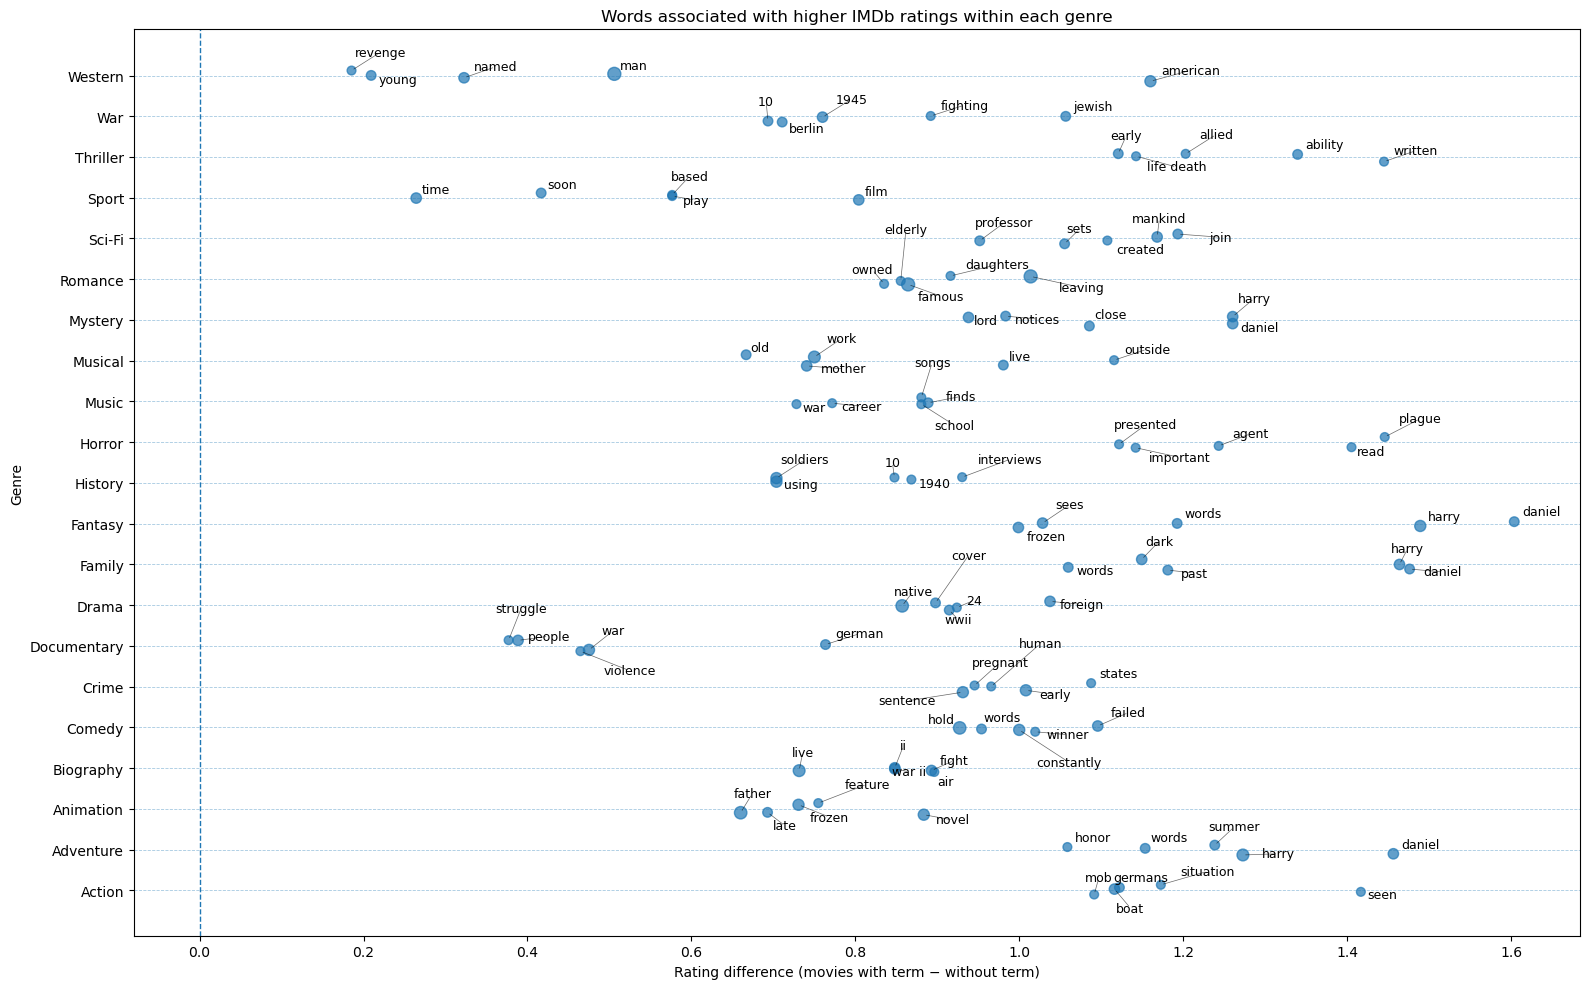

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# -----------------------------
# 1. Take top terms per genre
# -----------------------------
top_per_genre = 5
plot_df = (
    all_results.sort_values(["genre", "rating_difference"], ascending=[True, False])
    .groupby("genre")
    .head(top_per_genre)
    .copy()
)

# -----------------------------
# 2. Convert genre names to numeric y positions
# -----------------------------
genres = sorted(plot_df["genre"].unique())
genre_to_y = {genre: i for i, genre in enumerate(genres)}
plot_df["y"] = plot_df["genre"].map(genre_to_y)

# Add a little vertical jitter so points/labels do not start at exactly same place
np.random.seed(42)
plot_df["y_jitter"] = plot_df["y"] + np.random.uniform(-0.15, 0.15, size=len(plot_df))

# -----------------------------
# 3. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 10))

ax.scatter(
    plot_df["rating_difference"],
    plot_df["y_jitter"],
    s=plot_df["n_with_term"] * 8,
    alpha=0.7
)

# Horizontal guide lines
for genre, y in genre_to_y.items():
    ax.axhline(y=y, linestyle="--", linewidth=0.6, alpha=0.4)

# Vertical reference line
ax.axvline(0, linestyle="--", linewidth=1)

# -----------------------------
# 4. Add labels
# -----------------------------
texts = []
for _, row in plot_df.iterrows():
    texts.append(
        ax.text(
            row["rating_difference"],
            row["y_jitter"],
            row["term"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand=(1.2, 1.4),
    force_text=(0.8, 1.2),
    force_points=(0.5, 0.8),
    arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.6)
)

# -----------------------------
# 5. Format axes
# -----------------------------
ax.set_yticks(list(genre_to_y.values()))
ax.set_yticklabels(list(genre_to_y.keys()))

ax.set_xlabel("Rating difference (movies with term − without term)")
ax.set_ylabel("Genre")
ax.set_title("Words associated with higher IMDb ratings within each genre")

plt.tight_layout()
plt.show()

In [13]:
# Count number of times superhero is mentioned in the plot summaries 
superhero_count = df_text["plot_clean"].str.contains("superhero", case=False, na=False).sum()
print(f"The word 'superhero' is mentioned in {superhero_count} plot summaries.")



The word 'superhero' is mentioned in 1 plot summaries.


# Bert clustering


In [18]:
# Use bert embedings to clutster similar movies together based on their plot summaries
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
df_text = df[['plotMedium']].dropna().copy()
embeddings = model.encode(df_text['plotMedium'].tolist(), show_progress_bar=True)
print("Embeddings shape: ", embeddings.shape)

# Cluster movies using KMeans
from sklearn.cluster import KMeans
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_text['cluster'] = kmeans.fit_predict(embeddings)
print(df_text['cluster'].value_counts())


  Using cached sentence_transformers-5.2.3-py3-none-any.whl.metadata (16 kB)
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached hf_xet-1.3.2-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cudnn_cu12-9.10.2.21-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  U

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

Embeddings shape:  (2000, 384)
cluster
5    296
2    275
4    239
8    218
6    196
7    196
1    189
0    145
9    130
3    116
Name: count, dtype: int64


In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd

# --- embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
df_text = df[['plotMedium']].copy()
texts = df_text['plotMedium'].tolist()

embeddings = model.encode(texts, show_progress_bar=True)

# --- clustering ---
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_text['cluster'] = kmeans.fit_predict(embeddings)

# --- tf-idf for naming ---
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2
)
X_tfidf = vectorizer.fit_transform(df_text['plotMedium'])
terms = np.array(vectorizer.get_feature_names_out())

global_mean = np.asarray(X_tfidf.mean(axis=0)).ravel()
cluster_names = {}

for c in sorted(df_text['cluster'].unique()):
    mask = df_text['cluster'] == c
    cluster_mean = np.asarray(X_tfidf[mask].mean(axis=0)).ravel()
    distinctive_score = cluster_mean - global_mean
    top_idx = distinctive_score.argsort()[::-1][:5]
    top_terms = terms[top_idx]
    cluster_names[c] = "_".join(t.title() for t in top_terms[:3])

df_text['cluster_name'] = df_text['cluster'].map(cluster_names)

# --- summary ---
summary = (
    df_text.groupby(['cluster', 'cluster_name'])
    .size()
    .reset_index(name='movie_count')
    .sort_values('movie_count', ascending=False)
)

print(summary)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

   cluster               cluster_name  movie_count
2        2       Love_Husband_Married          306
5        5          Mother_Girl_Woman          305
7        7    Police_Prison_Detective          284
3        3            Tom_School_Boys          227
4        4           Count_Dr_Dracula          179
0        0            Earth_Team_Crew          158
1        1  Christmas_Adventure_Novel          154
9        9          King_Prince_Magic          145
8        8         Film_Story_Society          127
6        6         German_War_British          115
